# Import libraries

In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Load dataset

In [2]:
loan_dataset = pd.read_csv("Loan Modelling Thera Bank.csv")
loan_dataset

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


# Data Preprocessing

In [3]:
X = loan_dataset.drop(['Personal Loan', 'ID'], axis=1)
X = (X-X.min())/(X.max()-X.min())

In [4]:
Y = loan_dataset['Personal Loan']
Y

0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: Personal Loan, Length: 5000, dtype: int64

## Split train and test


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=30)
print(f"Dữ liệu training =  {X_train.shape}, {Y_train.shape}")
print(f"Dữ liệu testing =  {X_test.shape}, {Y_test.shape}")

Dữ liệu training =  (4000, 12), (4000,)
Dữ liệu testing =  (1000, 12), (1000,)


# Evaluate impact of different values of n_neighbors

In [20]:
models = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2, weights='distance')
    knn.fit(X_train, Y_train)
    models.append(knn)



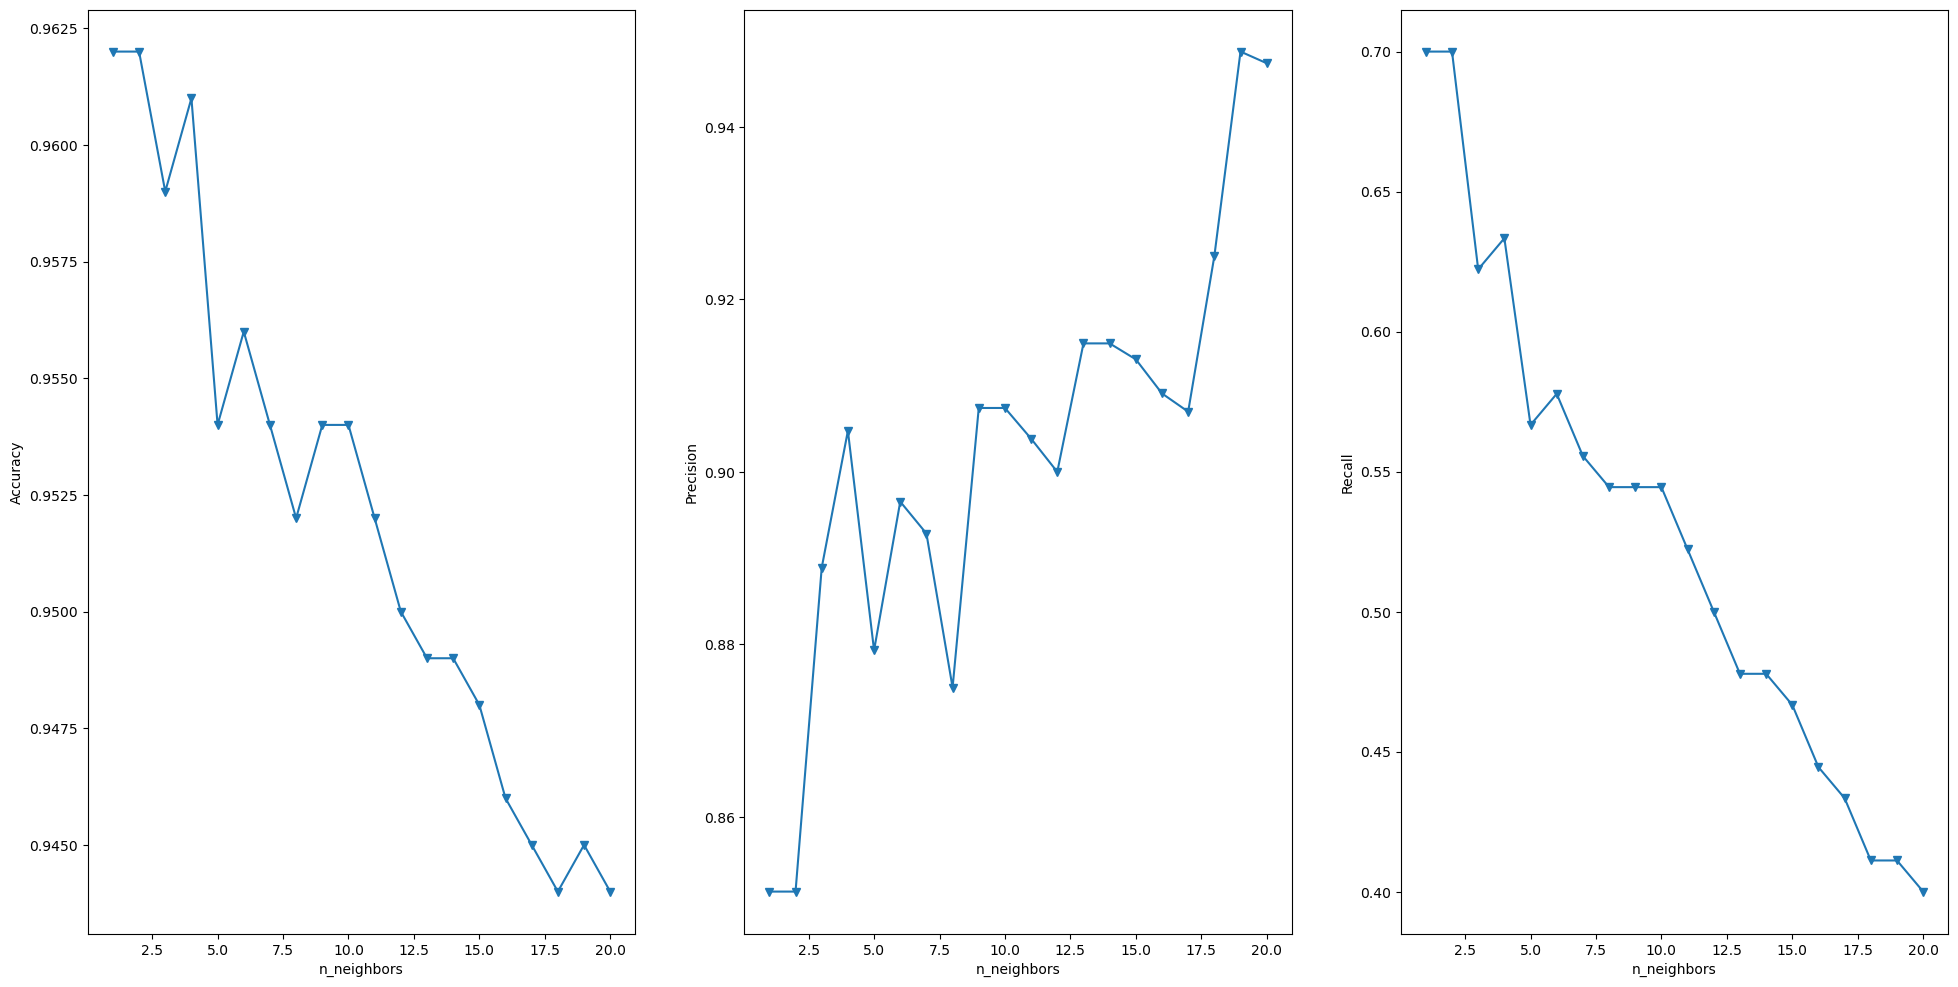

In [28]:
# Visualize
accuracy, precision, recall = [], [], []
for model in models:
    y_pred = model.predict(X_test)
    accuracy.append(accuracy_score(Y_test, y_pred))
    precision.append(precision_score(Y_test, y_pred))
    recall.append(recall_score(Y_test, y_pred))

fig, axs = plt.subplots(1, 3, figsize=(24, 12))

n_neighbors = list(range(1, 21))

axs[0].plot(n_neighbors, accuracy, marker="v")
axs[0].set_xlabel("n_neighbors")
axs[0].set_ylabel("Accuracy")

axs[1].plot(n_neighbors, precision, marker="v")
axs[1].set_xlabel("n_neighbors")
axs[1].set_ylabel("Precision")

axs[2].plot(n_neighbors, recall, marker="v")
axs[2].set_xlabel("n_neighbors")
axs[2].set_ylabel("Recall")

plt.show()

# Evaluate impact of each attribute

In [9]:
loan_dataset.keys()

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='str')

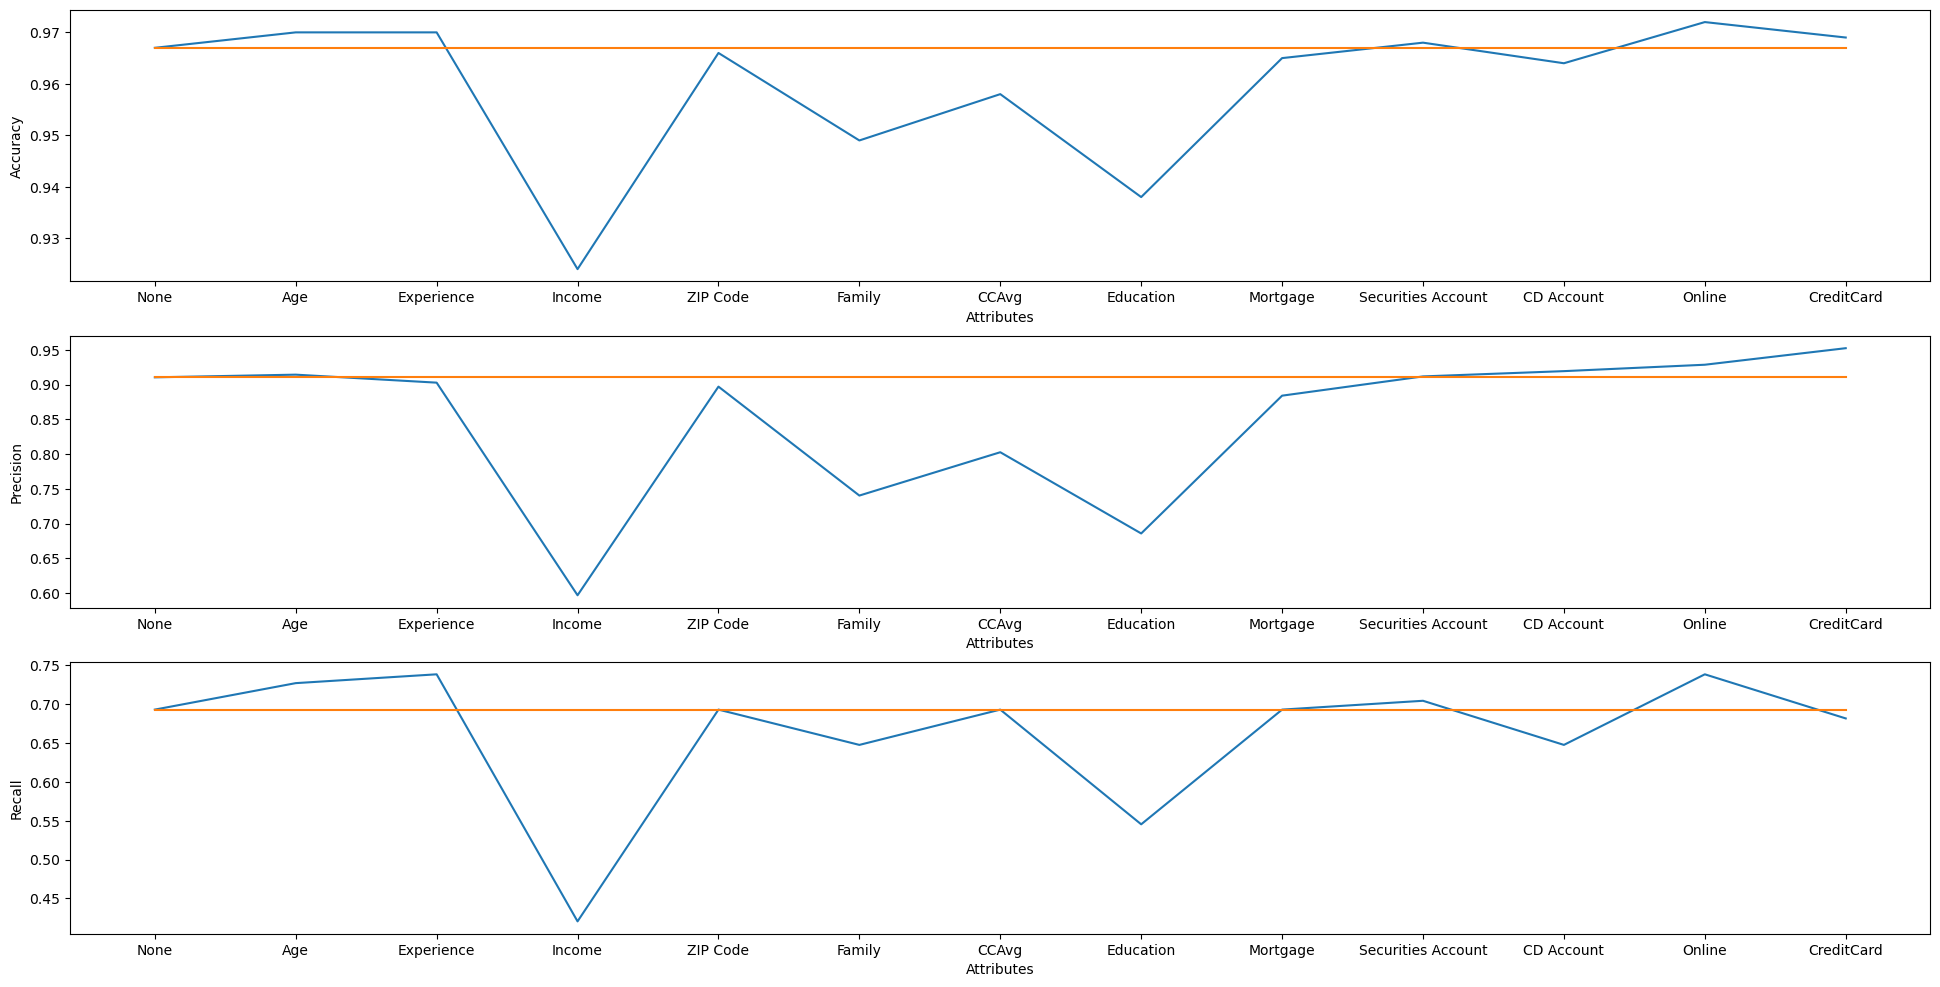

In [14]:
models = []
acc, pre, re = [], [], []
attrs = ['None','Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage',
        'Securities Account', 'CD Account', 'Online', 'CreditCard']
for attr in attrs:
    model = KNeighborsClassifier(n_neighbors=2, metric='minkowski', p=2, weights='distance')
    if attr == 'None':
        X = loan_dataset.drop(['Personal Loan', 'ID'], axis=1) 
    else:
        X = loan_dataset.drop(['Personal Loan', 'ID', attr], axis=1) 
    X = (X-X.min())/(X.max()-X.min())
    y = loan_dataset["Personal Loan"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc.append(accuracy_score( y_test, y_pred))
    pre.append(precision_score(y_test, y_pred))
    re.append(recall_score(y_test, y_pred))

#Visualize
fig, axs = plt.subplots(3, 1, figsize=(24, 12))
axs[0].plot(attrs, acc)
axs[0].set_xlabel("Attributes")
axs[0].set_ylabel("Accuracy")
axs[0].plot(attrs, [acc[0] for _ in range(len(acc))], marker = '', label = 'Baseline')

axs[1].plot(attrs, pre)
axs[1].set_xlabel("Attributes")
axs[1].set_ylabel("Precision")
axs[1].plot(attrs, [pre[0] for _ in range(len(pre))], marker = '', label = 'Baseline')

axs[2].plot(attrs, re)   
axs[2].set_xlabel("Attributes")
axs[2].set_ylabel("Recall")
axs[2].plot(attrs, [re[0] for _ in range(len(re))], marker = '', label = 'Baseline')

plt.show()
